
# Classification Models with Keras





The <strong>MNIST database</strong>, short for Modified National Institute of Standards and Technology database, is a large database of handwritten digits that is commonly used for training various image processing systems. The database is also widely used for training and testing in the field of machine learning.
    
The MNIST database contains 60,000 training images and 10,000 testing images of digits written by high school students and employees of the United States Census Bureau.

Also, this way, you will get to compare how conventional neural networks compare to convolutional neural networks, that we will build in the next module.


In [31]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [32]:
import keras

from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
from keras.utils import to_categorical

Since we are dealing we images, let's also import the Matplotlib scripting layer in order to view the images.


In [33]:
import matplotlib.pyplot as plt

The Keras library conveniently includes the MNIST dataset as part of its API. You can check other datasets within the Keras library [here](https://keras.io/datasets/). 

So, let's load the MNIST dataset from the Keras library. The dataset is readily divided into a training set and a test set.


In [34]:
# import the data
from keras.datasets import mnist

# read the data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

Let's confirm the number of images in each set. According to the dataset's documentation, we should have 60000 images in X_train and 10000 images in the X_test.


In [35]:
X_train.dtype

dtype('uint8')

In [36]:
X_train.shape

(60000, 28, 28)

The first number in the output tuple is the number of images, and the other two numbers are the size of the images in datset. So, each image is 28 pixels by 28 pixels.


Let's visualize the first image in the training set using Matplotlib's scripting layer.


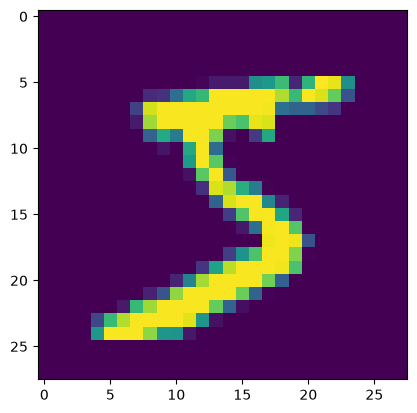

In [37]:
plt.imshow(X_train[0])

With conventional neural networks, we cannot feed in the image as input as is. So we need to flatten the images into one-dimensional vectors, each of size 1 x (28 x 28) = 1 x 784.


In [38]:
# flatten images into one-dimensional vector

num_pixels = X_train.shape[1] * X_train.shape[2] # find size of one-dimensional vector

X_train = X_train.reshape(X_train.shape[0], num_pixels).astype('float32') # flatten training images
X_test = X_test.reshape(X_test.shape[0], num_pixels).astype('float32') # flatten test images

Since pixel values can range from 0 to 255, let's normalize the vectors to be between 0 and 1.


In [39]:
# normalize inputs from 0-255 to 0-1
X_train = X_train / 255
X_test = X_test / 255

Finally, before we start building our model, remember that for classification we need to divide our target variable into categories. We use the to_categorical function from the Keras Utilities package.


In [40]:
# one hot encode outputs
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

num_classes = y_test.shape[1]
print(num_classes)
print(y_test[1])


10
[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


## Build a Neural Network


In [41]:
# define classification model
def classification_model():
    # create model
    
    model = Sequential()
    model.add(Input(shape=(num_pixels,)))
    model.add(Dense(num_pixels, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    
    
    # compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

## Train and Test the Network


In [42]:
# build the model
model = classification_model()

# fit the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=2)

# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)

Epoch 1/10


1875/1875 - 24s - 13ms/step - accuracy: 0.9432 - loss: 0.1853 - val_accuracy: 0.9706 - val_loss: 0.0951
Epoch 2/10
1875/1875 - 22s - 12ms/step - accuracy: 0.9738 - loss: 0.0792 - val_accuracy: 0.9733 - val_loss: 0.0848
Epoch 3/10
1875/1875 - 21s - 11ms/step - accuracy: 0.9829 - loss: 0.0540 - val_accuracy: 0.9799 - val_loss: 0.0693
Epoch 4/10
1875/1875 - 18s - 10ms/step - accuracy: 0.9873 - loss: 0.0394 - val_accuracy: 0.9748 - val_loss: 0.0937
Epoch 5/10
1875/1875 - 20s - 10ms/step - accuracy: 0.9899 - loss: 0.0302 - val_accuracy: 0.9761 - val_loss: 0.0914
Epoch 6/10
1875/1875 - 20s - 11ms/step - accuracy: 0.9913 - loss: 0.0253 - val_accuracy: 0.9778 - val_loss: 0.0908
Epoch 7/10
1875/1875 - 21s - 11ms/step - accuracy: 0.9928 - loss: 0.0219 - val_accuracy: 0.9810 - val_loss: 0.0805
Epoch 8/10
1875/1875 - 20s - 11ms/step - accuracy: 0.9934 - loss: 0.0194 - val_accuracy: 0.9778 - val_loss: 0.0930
Epoch 9/10
1875/1875 - 21s - 11ms/step - accuracy: 0.9943 - loss: 0.0177 - val_accuracy: 0.

Let's print the accuracy and the corresponding error.


In [43]:
print('Accuracy: {}% \n Error: {}'.format(scores[1], 1 - scores[1]))        

Accuracy: 0.9778000116348267% 
 Error: 0.02219998836517334


Sometimes, you cannot afford to retrain your model everytime you want to use it, especially if you are limited on computational resources and training your model can take a long time. Therefore, with the Keras library, you can save your model after training. To do that, we use the save method.


In [44]:
model.save('classification_model.keras')

Since our model contains multidimensional arrays of data, then models are usually saved as .keras files.


When you are ready to use your model again, you use the load_model function from <strong>keras.saving</strong>.


In [45]:
pretrained_model = keras.saving.load_model('classification_model.keras')

<h3>Practice Exercise 1</h3>


Create a neural network model with 6 dense layers and compare its accuracy


In [48]:
def classification_model_6layers():
    # create model
    
    model = Sequential()
    model.add(Input(shape=(num_pixels,)))
    model.add(Dense(num_pixels, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    
    
    # compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# build the model
model_6layers = classification_model_6layers()

# fit the model
model_6layers.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=2)

# evaluate the model
scores_6layers = model_6layers.evaluate(X_test, y_test, verbose=0)

print('Accuracy_3_layers: {}% \n Accuracy_6_layers: {}'.format(scores[1], scores_6layers[1]))  

Epoch 1/10
1875/1875 - 24s - 13ms/step - accuracy: 0.9349 - loss: 0.2207 - val_accuracy: 0.9653 - val_loss: 0.1224
Epoch 2/10
1875/1875 - 24s - 13ms/step - accuracy: 0.9704 - loss: 0.0995 - val_accuracy: 0.9656 - val_loss: 0.1203
Epoch 3/10
1875/1875 - 21s - 11ms/step - accuracy: 0.9786 - loss: 0.0739 - val_accuracy: 0.9743 - val_loss: 0.0857
Epoch 4/10
1875/1875 - 20s - 10ms/step - accuracy: 0.9828 - loss: 0.0585 - val_accuracy: 0.9741 - val_loss: 0.0899
Epoch 5/10
1875/1875 - 19s - 10ms/step - accuracy: 0.9863 - loss: 0.0467 - val_accuracy: 0.9786 - val_loss: 0.0824
Epoch 6/10
1875/1875 - 20s - 11ms/step - accuracy: 0.9882 - loss: 0.0406 - val_accuracy: 0.9728 - val_loss: 0.1046
Epoch 7/10
1875/1875 - 20s - 11ms/step - accuracy: 0.9897 - loss: 0.0365 - val_accuracy: 0.9837 - val_loss: 0.0653
Epoch 8/10
1875/1875 - 20s - 11ms/step - accuracy: 0.9916 - loss: 0.0301 - val_accuracy: 0.9807 - val_loss: 0.0744
Epoch 9/10
1875/1875 - 20s - 10ms/step - accuracy: 0.9918 - loss: 0.0286 - val_a

<h3>Practice Exercise 2</h3>


Now, load the the earlier saved model, train it further for 10 more epochs and check the accuracy


In [49]:
pretrained_model = keras.saving.load_model('classification_model.keras')

print("Pre-trained model loaded successufully")

# Further train the loaded model
pretrained_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=2)

# evaluate the model
scores_20_epochs = pretrained_model.evaluate(X_test, y_test, verbose=0)
print('Accuracy_10_epochs: {}% \n Accuracy_20_epochs: {}'.format(scores[1], scores_20_epochs[1]))   

Pre-trained model loaded successufully
Epoch 1/10
1875/1875 - 29s - 15ms/step - accuracy: 0.9954 - loss: 0.0139 - val_accuracy: 0.9817 - val_loss: 0.0925
Epoch 2/10
1875/1875 - 33s - 17ms/step - accuracy: 0.9952 - loss: 0.0148 - val_accuracy: 0.9795 - val_loss: 0.1037
Epoch 3/10
1875/1875 - 29s - 16ms/step - accuracy: 0.9960 - loss: 0.0127 - val_accuracy: 0.9818 - val_loss: 0.1134
Epoch 4/10
1875/1875 - 20s - 11ms/step - accuracy: 0.9966 - loss: 0.0123 - val_accuracy: 0.9801 - val_loss: 0.1054
Epoch 5/10
1875/1875 - 20s - 10ms/step - accuracy: 0.9962 - loss: 0.0120 - val_accuracy: 0.9818 - val_loss: 0.1090
Epoch 6/10
1875/1875 - 19s - 10ms/step - accuracy: 0.9965 - loss: 0.0126 - val_accuracy: 0.9823 - val_loss: 0.1141
Epoch 7/10
1875/1875 - 19s - 10ms/step - accuracy: 0.9967 - loss: 0.0114 - val_accuracy: 0.9790 - val_loss: 0.1278
Epoch 8/10
1875/1875 - 19s - 10ms/step - accuracy: 0.9972 - loss: 0.0097 - val_accuracy: 0.9767 - val_loss: 0.1436
Epoch 9/10
1875/1875 - 18s - 10ms/step - 